### Indexing
- 文档切分：上下文影响
- 文本嵌入：词向量
- 向量存储：存储进入向量数据库

In [ ]:
question = "What kinds of pets do I like?"
document = "My favorite pet is a cat."

In [2]:
# split
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(question, "cl100k_base")


8

In [3]:
from langchain_community.embeddings import HuggingFaceEmbeddings

EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)

query_result = embeddings.embed_query(question)         
document_result = embeddings.embed_documents(document)    
print(query_result)
print(document_result)

C:\Users\23017\AppData\Local\Temp\ipykernel_26016\3959025914.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1131.37it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+-

[0.030804593116044998, -0.054369475692510605, 0.10352049022912979, 0.04905471205711365, -0.1011802926659584, 0.016317298635840416, 0.06456959247589111, -0.10090930759906769, 0.03199335187673569, 0.06234780326485634, 0.015311219729483128, -0.09542012959718704, -0.08276786655187607, 0.06763670593500137, 0.03019924834370613, 0.01477630715817213, 0.037524838000535965, 0.011401204392313957, 0.038599077612161636, 0.02259024791419506, -0.06538227200508118, -0.005343545228242874, 0.026571040973067284, -0.04201488941907883, -0.1649920791387558, 0.003846024628728628, -0.049971748143434525, -0.039818234741687775, -0.007290679961442947, -0.0517585426568985, -0.052676744759082794, -0.004307559225708246, -0.017732396721839905, -0.026814410462975502, -0.000605517125222832, -0.058068353682756424, 0.00174462900031358, 0.031995344907045364, 0.032825831323862076, 0.07603496313095093, -0.02352978102862835, 0.015722163021564484, 0.10195265710353851, 0.012027835473418236, -0.07781646400690079, -0.1036248430

In [5]:
# cosine similarity
import numpy as np 
def cosine_similarity(a, b):
    doc_product = np.dot(a,b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return doc_product / (norm_a * norm_b)

similarity = cosine_similarity(query_result, document_result[0])  # document_result是一个列表，取第一个元素
print(similarity)

0.08806105754739502


以一个blog为例

In [6]:
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [9]:
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) #关键K值

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1118.34it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tags=['Chroma', 'HuggingFaceEmbeddings'] vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002B080FE4FD0> search_kwargs={'k': 3}


C:\Users\23017\AppData\Local\Temp\ipykernel_26016\624741754.py:15: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()  # 持久化存储


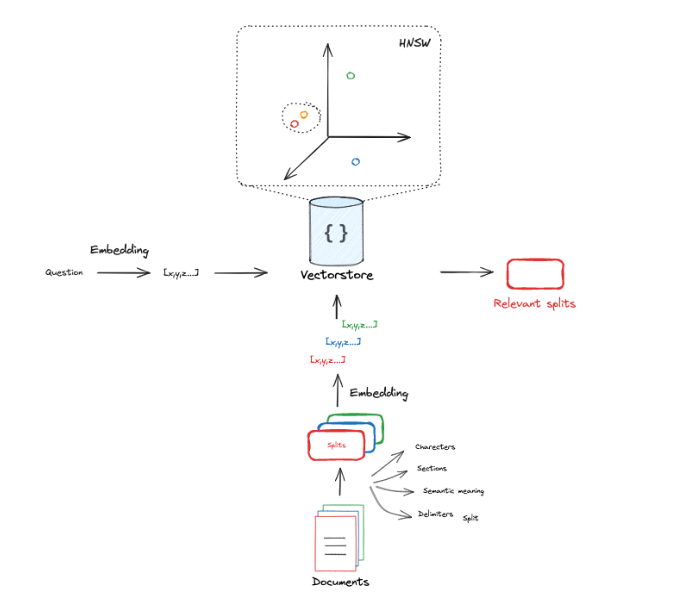